# Klasifikacija

**Glavni cilj:** predvideti koji algoritam (AB ili MCTS) bira **bolji** potez (`which_better`)

**Sporedni cilj:** koji algoritam pronalazi **optimalni** potez (`which_algo`)

**Pristup:** poređenje skupova atributa: tri skupa atributa (A: pretprocesirani, B: strukturni, C: originalni), XGBoost sa monotonim domenskim ograničenjima, SHAP analiza važnosti

*which_algo meša "koliko je algoritam dobar" sa "koliko je stablo teško" i teže ga je predvideti

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.tree import plot_tree
import xgboost as xgb
from xgboost import XGBClassifier

from theme import *

In [2]:
Path("../plots/classification").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/trees_preprocessed.csv")
df_orig = pd.read_csv("../data/trees10.csv")

print(f"Pretprocesirani skup: {df.shape[0]} redova, {df.shape[1]} kolona")
print(f"Originalni skup: {df_orig.shape[0]} redova, {df_orig.shape[1]} kolona")

Pretprocesirani skup: 16978 redova, 49 kolona
Originalni skup: 16978 redova, 91 kolona


In [3]:
TARGET_COLS = [
    "which_algo", "which_algo_enc",
    "which_better", "which_better_enc", "is_tie",
    "ab_correct", "mcts_correct", "mcts_correct_rate",
    "is_contested", "margin_category", "margin_category_enc",
    "tree_difficulty", "tree_difficulty_enc",
    "delta", "ab_regret", "mcts_regret",
]

feat_A = [c for c in df.columns if c not in TARGET_COLS]

# algo-behavioral
ALGO_BEHAVIORAL = [
    "ab_nodes_visited", "ab_pruning_rate", "ab_root_eval_std",
    "ab_instability", "ab_depth_reached", "ab_ranking_correlation",
    "mcts_visit_entropy", "mcts_vote_margin", "mcts_best_value_estimate",
    "exact_best_value", "exact_second_best_value",
    "best_move_margin", "best_move_margin_normalized",
    "mcts_unanimous", "ab_coverage",
]
feat_B_base = [f for f in feat_A if f not in ALGO_BEHAVIORAL]

EXTRA_STRUCTURAL_CANDIDATES = [
    "leaf_to_internal_ratio", "node_count_d3", "depth_deficit",
    "leaf_value_std_d2", "chance_node_count_d2", "total_max_nodes",
    "heur_noise_param",
]
EXTRA_STRUCTURAL = [f for f in EXTRA_STRUCTURAL_CANDIDATES if f not in feat_B_base and f in df_orig.columns]
feat_B = feat_B_base + EXTRA_STRUCTURAL

skip_orig = set(TARGET_COLS)
feat_C = [c for c in df_orig.select_dtypes("number").columns if c not in skip_orig]

X_A = df[feat_A].values
X_B = pd.concat([df[feat_B_base], df_orig[EXTRA_STRUCTURAL]], axis=1).values
X_C = df_orig[feat_C].values

print(f"feat_A: {len(feat_A)} atributa  (finalni pretprocesirani)")
print(f"feat_B: {len(feat_B)} atributa  (strukturni: {len(feat_B_base)} iz 02 + {len(EXTRA_STRUCTURAL)} vracenih iz trees10.csv)")
print(f"feat_C: {len(feat_C)} atributa  (originalni skup)")

feat_A: 33 atributa  (finalni pretprocesirani)
feat_B: 28 atributa  (strukturni: 22 iz 02 + 6 vracenih iz trees10.csv)
feat_C: 81 atributa  (originalni skup)


## 1. Ciljni atributi

| Promenljiva | Tip | Pitanje |
|---|---|---|
| `which_better` | 3 klase (nominalna) | **glavni cilj**, novo u v10: čiji je izabrani potez bolji? (AB / MCTS / Tie) |
| `which_algo` | 4 klase (nominalna) | sporedni cilj: koji algoritam je tačan? (AB / Both / MCTS / Neither) |
| `ab_correct`, `mcts_correct` | binarne | da li je svaki algoritam pojedinačno bio tačan? |
| `margin_category` | 3 klase (ordinalna) | za koliko pobednik vodi? (low / medium / high) |
| `is_contested` | binarna | identično `margin_category == "low"` (isti prag: margin < 0.1) |
| `tree_difficulty` | 3 klase (ordinalna) | izvedeno iz `which_algo`: Both -> easy, AB/MCTS -> medium, Neither -> hard |
| `is_tie` | binarna | identično `which_better == "Tie"` |

## 2. which_better: glavni ciljni atribut

Problem: predikcija koji algoritam bira potez bolje vrednosti

**Metrika:** macro-F1: F1 je harmonijska sredina preciznosti i odziva (`2rp/(r+p)`); macro prosek daje jednaku težinu svakoj od 3 klase bez obzira na broj instanci

**Unakrsna validacija:** StratifiedKFold k=10 svuda: prikazuje mean ± std po foldu i daje predikcije za matrice konfuzije u jednom prolazu

**Poređenje skupova atributa:** isti modeli na tri skupa atributa:
- **A:** finalni pretprocesirani skup: sve dostupne informacije
- **B:** samo strukturni atributi stabla: bez podataka o ponašanju algoritama
- **C:** originalni skup pre smanjenja dimenzionalnosti

**Modeli:** Drvo odlučivanja (DT), Slučajne šume (RF), Logistička regresija (LR), XGBoost (XGB), Slaganje modela (DT+RF+XGB -> LR meta)

In [4]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

y_better = df["which_better_enc"].values

label_names = ["AB", "MCTS", "Tie"] 

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=1)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))
xgb_clf = XGBClassifier(n_estimators=150, random_state=42, verbosity=0, eval_metric="mlogloss", n_jobs=1)
mlp = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,), activation="relu", alpha=1e-4, max_iter=500, early_stopping=True, random_state=42))
svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
stacking = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)),
        ("xgb", XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric="mlogloss", n_jobs=1))
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    cv=3, n_jobs=1
)

In [5]:
from sklearn.base import clone
from sklearn.utils.parallel import Parallel, delayed

def _fit_fold(model, X, y, train_idx, test_idx):
    m = clone(model)
    m.fit(X[train_idx], y[train_idx])
    preds = m.predict(X[test_idx])
    prob = m.predict_proba(X[test_idx])
    score = f1_score(y[test_idx], preds, average="macro")
    return test_idx, preds, prob, score

all_models = [("DT", dt), ("RF", rf), ("LR", lr), ("XGB", xgb_clf), ("MLP", mlp), ("SVM", svm), ("Stacking", stacking)]
feat_sets = [("A", X_A), ("B", X_B), ("C", X_C)]

results = {}
predictions = {}
probs = {}
n_classes = len(np.unique(y_better))

for set_name, X in feat_sets:
    results[set_name] = {}
    for name, model in all_models:
        if name == "Stacking" and set_name != "A":
            continue

        fold_results = Parallel(n_jobs=-1)(
            delayed(_fit_fold)(model, X, y_better, train_idx, test_idx)
            for train_idx, test_idx in cv10.split(X, y_better)
        )

        fold_scores = []
        preds_full = np.zeros(len(y_better), dtype=int)
        probs_full = np.zeros((len(y_better), n_classes))

        for test_idx, preds, prob, score in fold_results:
            preds_full[test_idx] = preds
            probs_full[test_idx] = prob
            fold_scores.append(score)

        mean, std = np.mean(fold_scores), np.std(fold_scores)
        results[set_name][name] = round(mean, 3)
        print(f"{set_name} | {name:10s}: {mean:.3f} ± {std:.3f}")

        if set_name == "A":
            predictions[name] = preds_full
            probs[name] = probs_full

feature_set_scores = pd.DataFrame(results).transpose()
print()
print("Poređenje skupova atributa: macro-F1 (k=10):")
feature_set_scores

A | DT        : 0.622 ± 0.014


A | RF        : 0.679 ± 0.007


A | LR        : 0.679 ± 0.012


A | XGB       : 0.689 ± 0.009


A | MLP       : 0.689 ± 0.012


...

C | LR        : 0.652 ± 0.013


C | XGB       : 0.664 ± 0.015


C | MLP       : 0.660 ± 0.012


C | SVM       : 0.656 ± 0.013

Poređenje skupova atributa: macro-F1 (k=10):


,DT,RF,LR,XGB,MLP,SVM,Stacking
A,0.622,0.679,0.679,0.689,0.689,0.682,0.692
B,0.470,0.554,0.557,0.556,0.561,0.554,NaN
C,0.564,0.649,0.652,0.664,0.660,0.656,NaN


### 2.2 Matrica konfuzije za sve modele



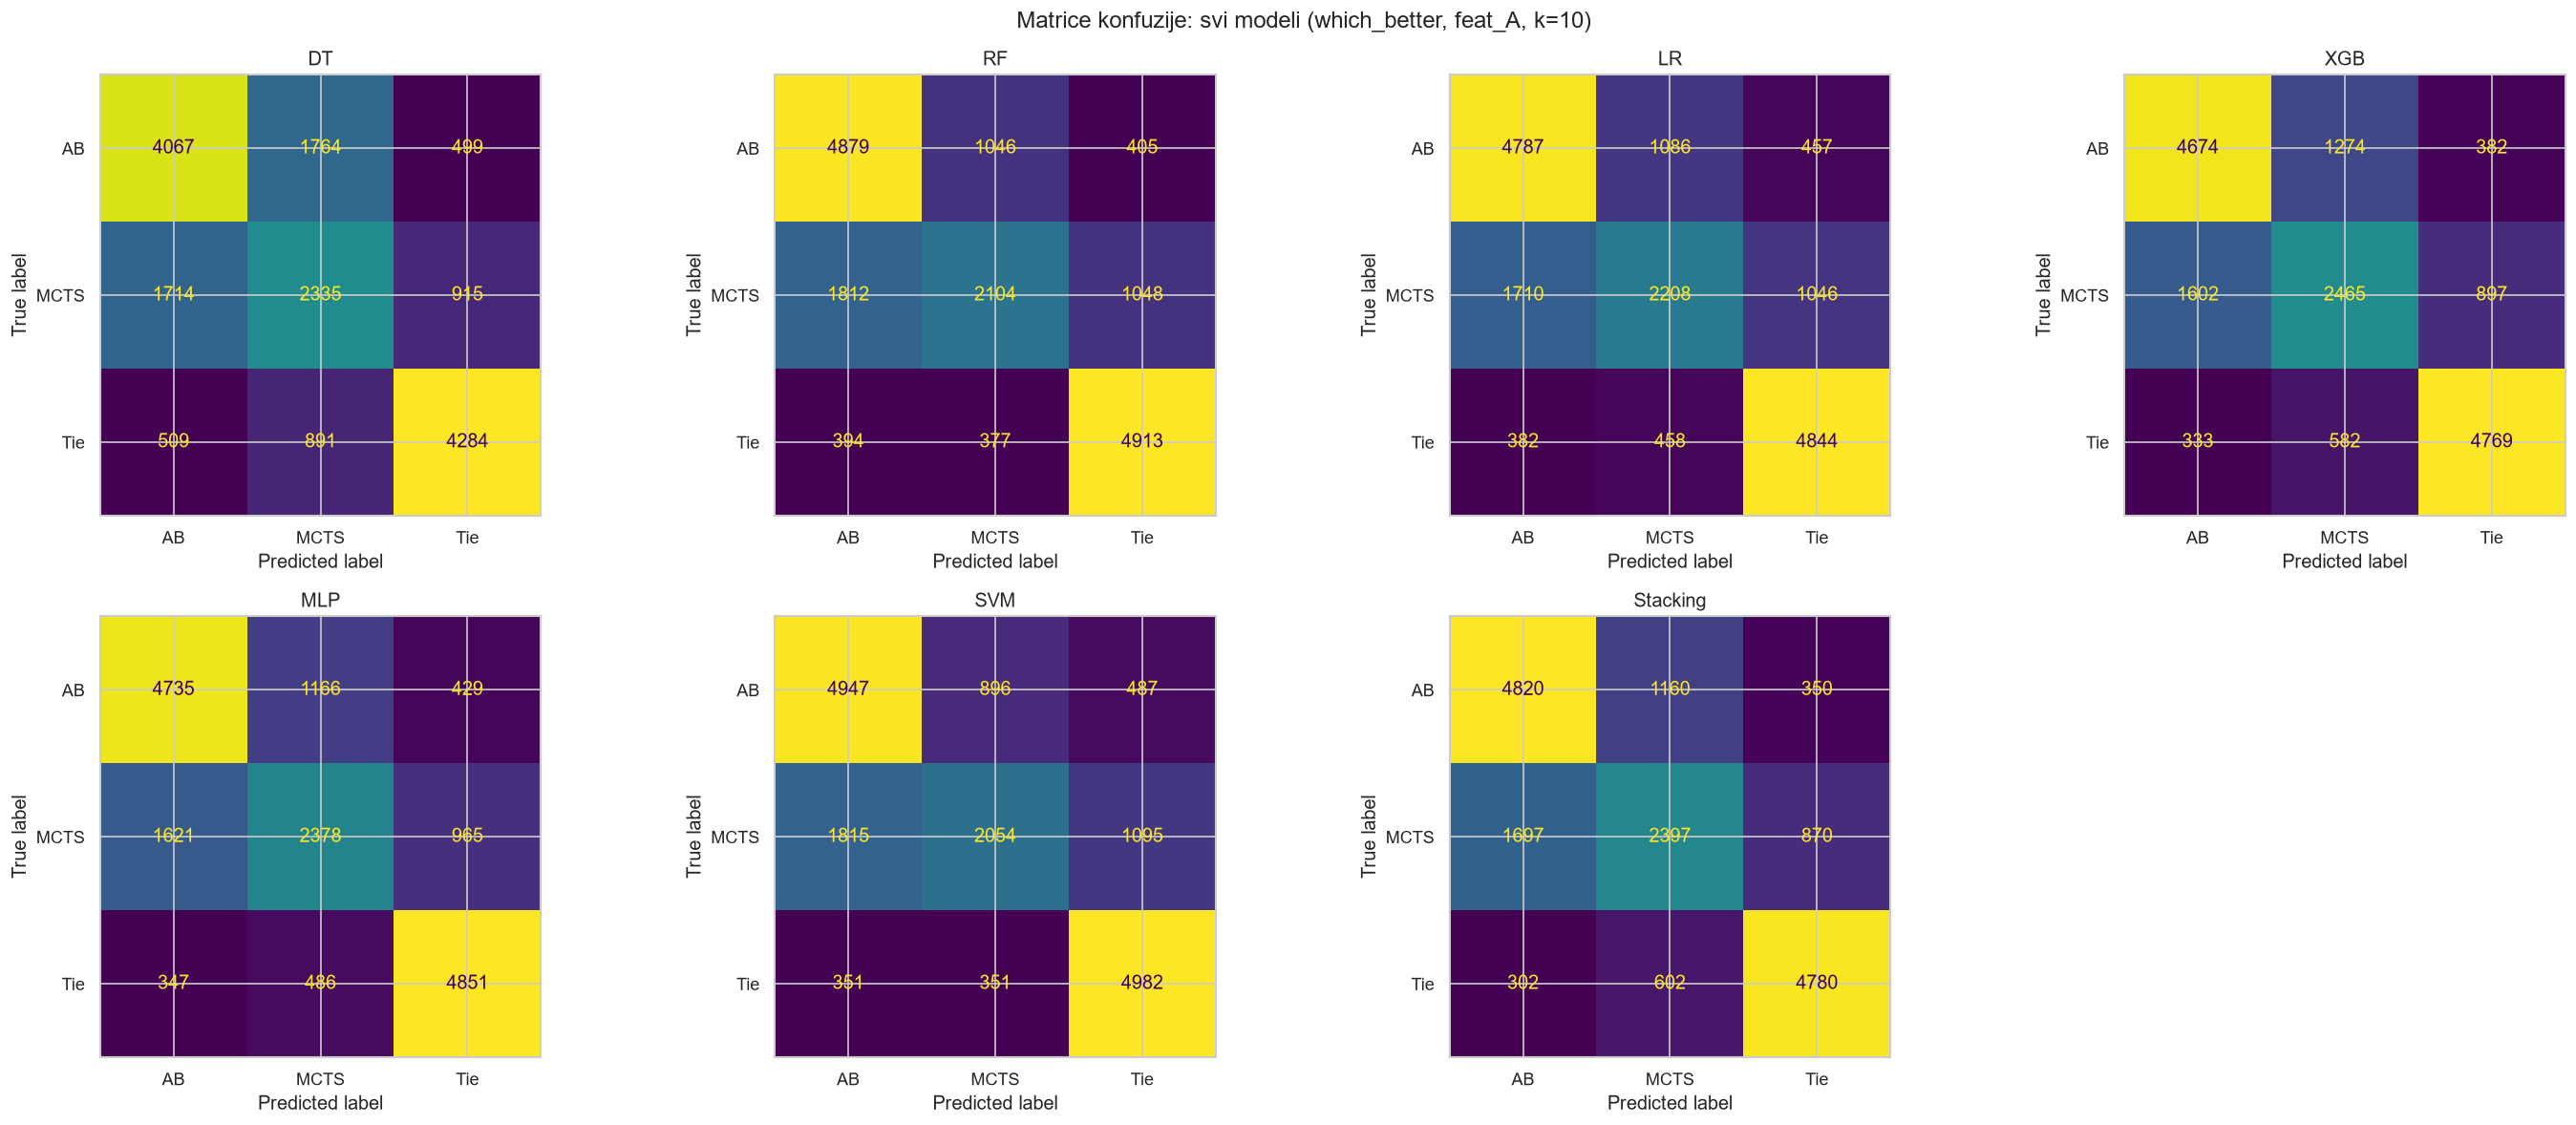

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_better, preds,
        display_labels=label_names,
        ax=axes_flat[i], colorbar=False
    )
    axes_flat[i].set_title(name)

for j in range(len(predictions), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Matrice konfuzije: svi modeli (which_better, feat_A, k=10)")
plt.tight_layout()
plt.savefig("../plots/classification/01_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.3 Binarni klasifikator (bez Tie stabala)

In [7]:
mask_nt = df["which_better"].values != "Tie"
X_A_nt = X_A[mask_nt]
y_better_nt = y_better[mask_nt]
labels_nt = [l for l in label_names if l != "Tie"]

print(f"Odbaceno {(~mask_nt).sum()} 'Tie' stabala ({(~mask_nt).mean():.1%}) - preostalo {mask_nt.sum()} redova\n")

predictions_nt = {}
for name, model in all_models:
    fold_results = Parallel(n_jobs=-1)(
        delayed(_fit_fold)(model, X_A_nt, y_better_nt, train_idx, test_idx)
        for train_idx, test_idx in cv10.split(X_A_nt, y_better_nt)
    )
    preds_full = np.zeros(len(y_better_nt), dtype=int)
    fold_scores = []
    for test_idx, preds, prob, score in fold_results:
        preds_full[test_idx] = preds
        fold_scores.append(score)
    predictions_nt[name] = preds_full
    print(f"{name:10s}: {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

Odbaceno 5684 'Tie' stabala (33.5%) - preostalo 11294 redova



DT        : 0.641 ± 0.015


RF        : 0.708 ± 0.015
LR        : 0.701 ± 0.013


XGB       : 0.697 ± 0.014


MLP       : 0.710 ± 0.017


SVM       : 0.711 ± 0.013


Stacking  : 0.713 ± 0.010


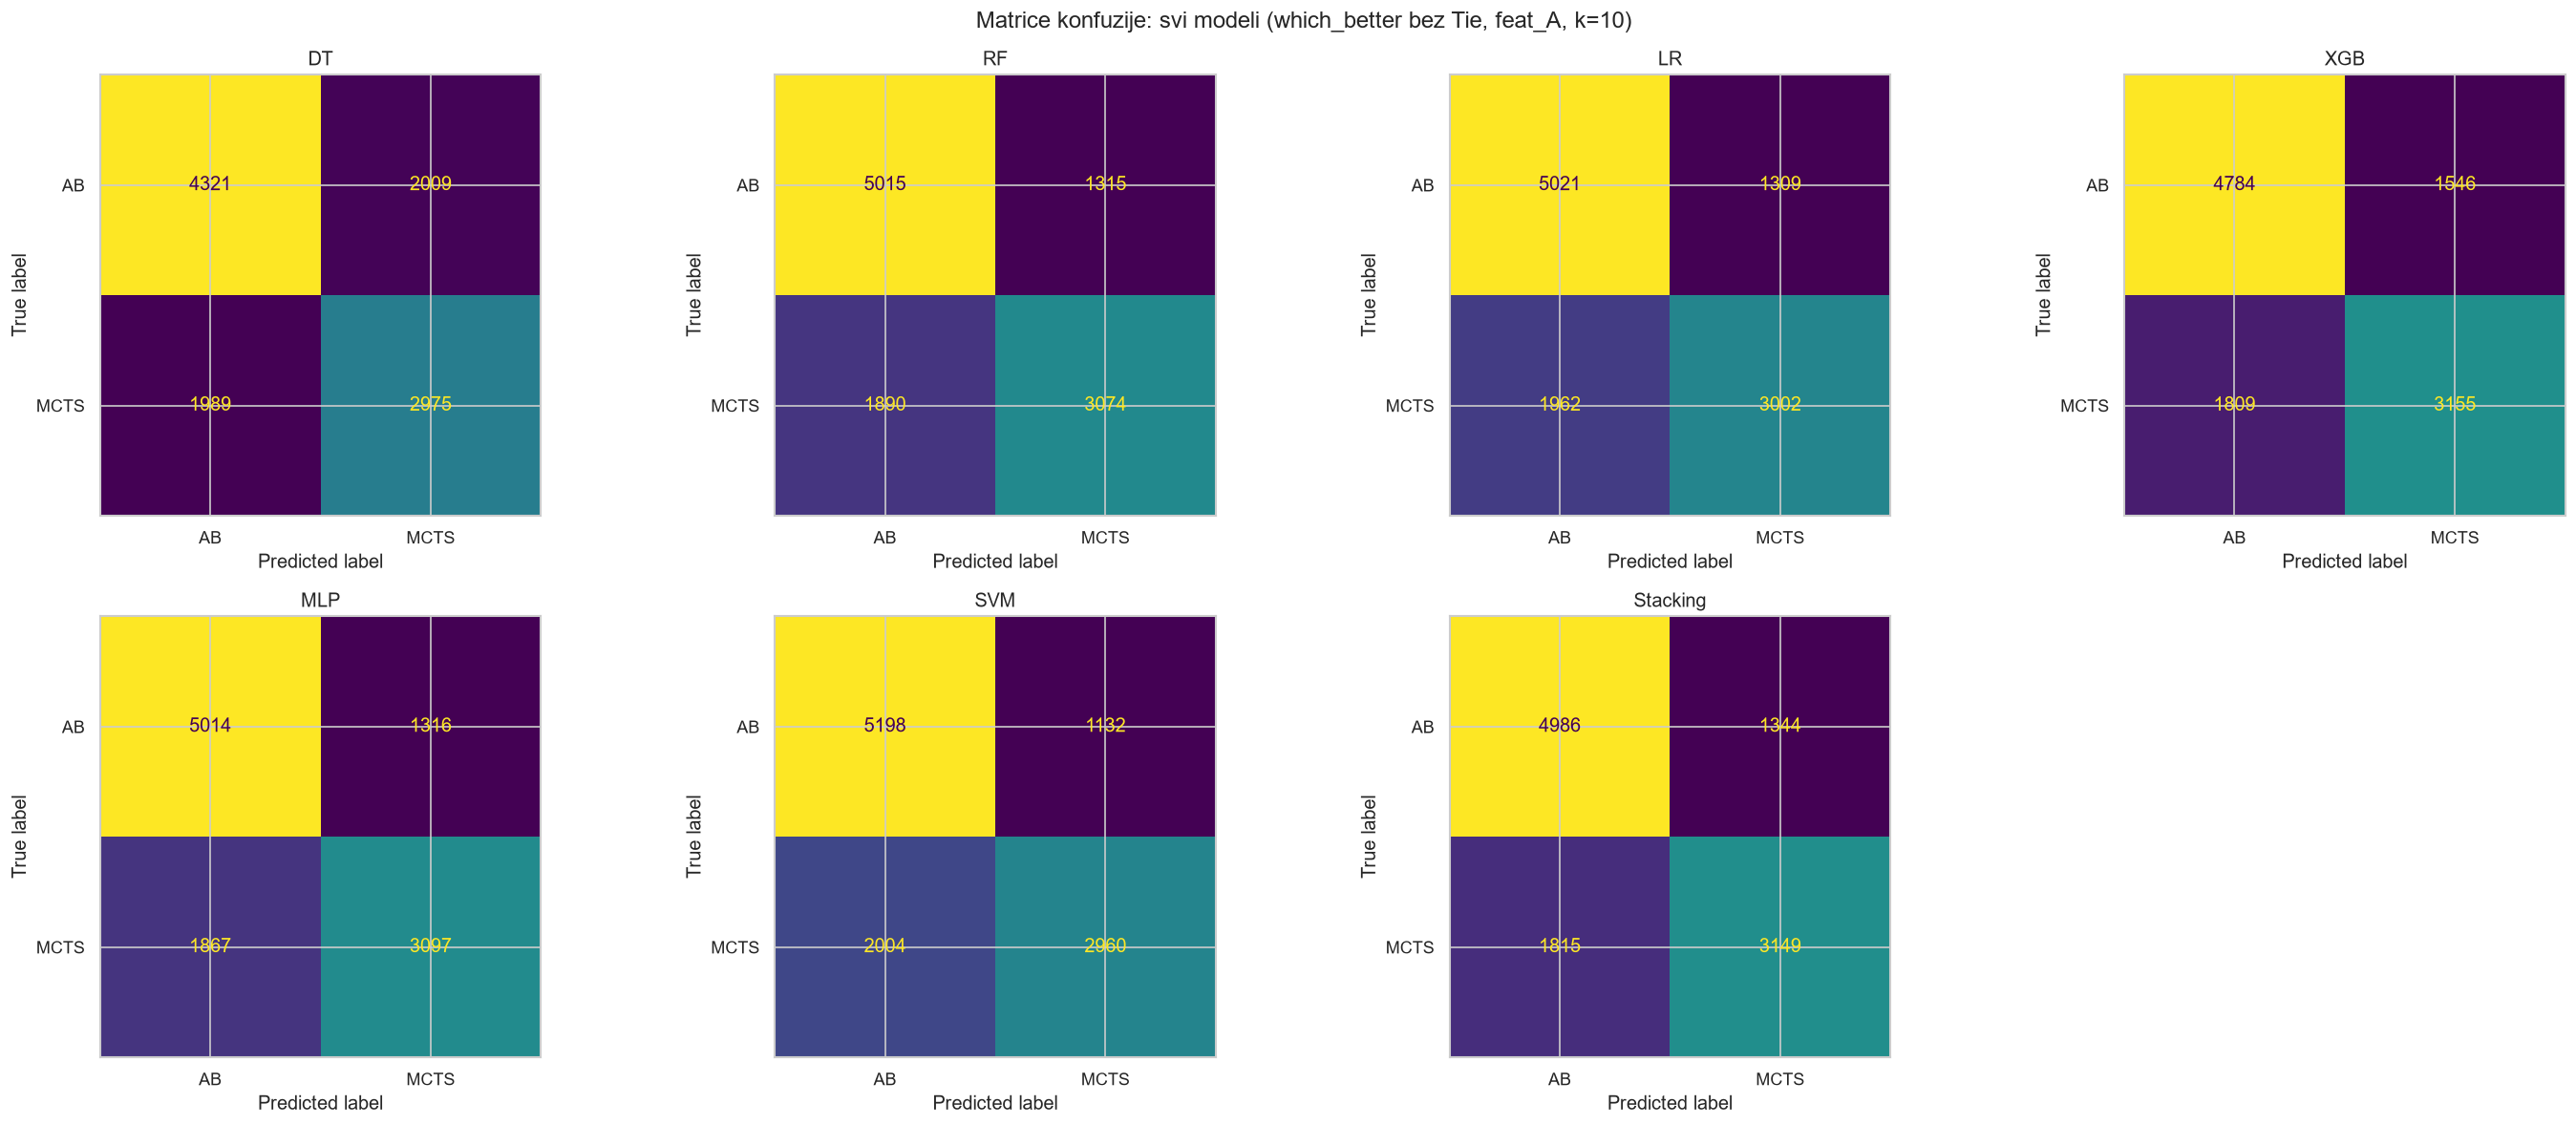

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(predictions_nt.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_better_nt, preds,
        display_labels=labels_nt,
        ax=axes_flat[i], colorbar=False
    )
    axes_flat[i].set_title(name)

for j in range(len(predictions_nt), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Matrice konfuzije: svi modeli (which_better bez Tie, feat_A, k=10)")
plt.tight_layout()
plt.savefig("../plots/classification/12_confusion_matrices_no_tie.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.3 Tačnost, Preciznost, Odziv, F1, ROC AUC

Zbirna tabela svih mera po modelu (macro: svaka klasa nosi jednaku težinu)

- **Tačnost:** `(TP+TN)/(TP+TN+FP+FN)`
- **Preciznost:** `TP/(TP+FP)`
- **Odziv:** `TP/(TP+FN)`
- **F1:** harmonijska sredina preciznosti i odziva `2rp/(r+p)`
- **ROC AUC:** površina ispod ROC krive (TPR vs FPR), bliže 1 = bolji model

In [9]:
rows = []
for name, preds in predictions.items():
    rows.append({
        "Model": name,
        "Tačnost": round(accuracy_score(y_better, preds), 3),
        "macro-F1": round(f1_score(y_better, preds, average="macro"), 3),
        "Preciznost": round(precision_score(y_better, preds, average="macro"), 3),
        "Odziv": round(recall_score(y_better, preds, average="macro"), 3),
        "ROC AUC (OvR)": round(roc_auc_score(y_better, probs[name], multi_class="ovr", average="macro"), 3),
    })

pd.DataFrame(rows).set_index("Model")

,Tačnost,macro-F1,Preciznost,Odziv,ROC AUC (OvR)
Model,,,,,
DT,0.629,0.622,0.622,0.622,0.719
RF,0.701,0.679,0.686,0.686,0.873
LR,0.697,0.679,0.683,0.684,0.870
XGB,0.701,0.689,0.689,0.691,0.876
MLP,0.705,0.690,0.691,0.694,0.876
SVM,0.706,0.682,0.692,0.691,0.872
Stacking,0.707,0.692,0.693,0.695,0.876


### 2.4 Drvo odlučivanja 

Drvo odlučivanja sa `max_depth=5` trenirano na strukturnim atributima stabla (feat_B),
bez atributa ponašanja algoritama. Prikazuje koje strukturne karakteristike stabla
predviđaju čiji je potez bolji i na kom pragu

Tačnost na trening skupu (max_depth=5): 0.589
Koren deli po: node_budget <= 130.500


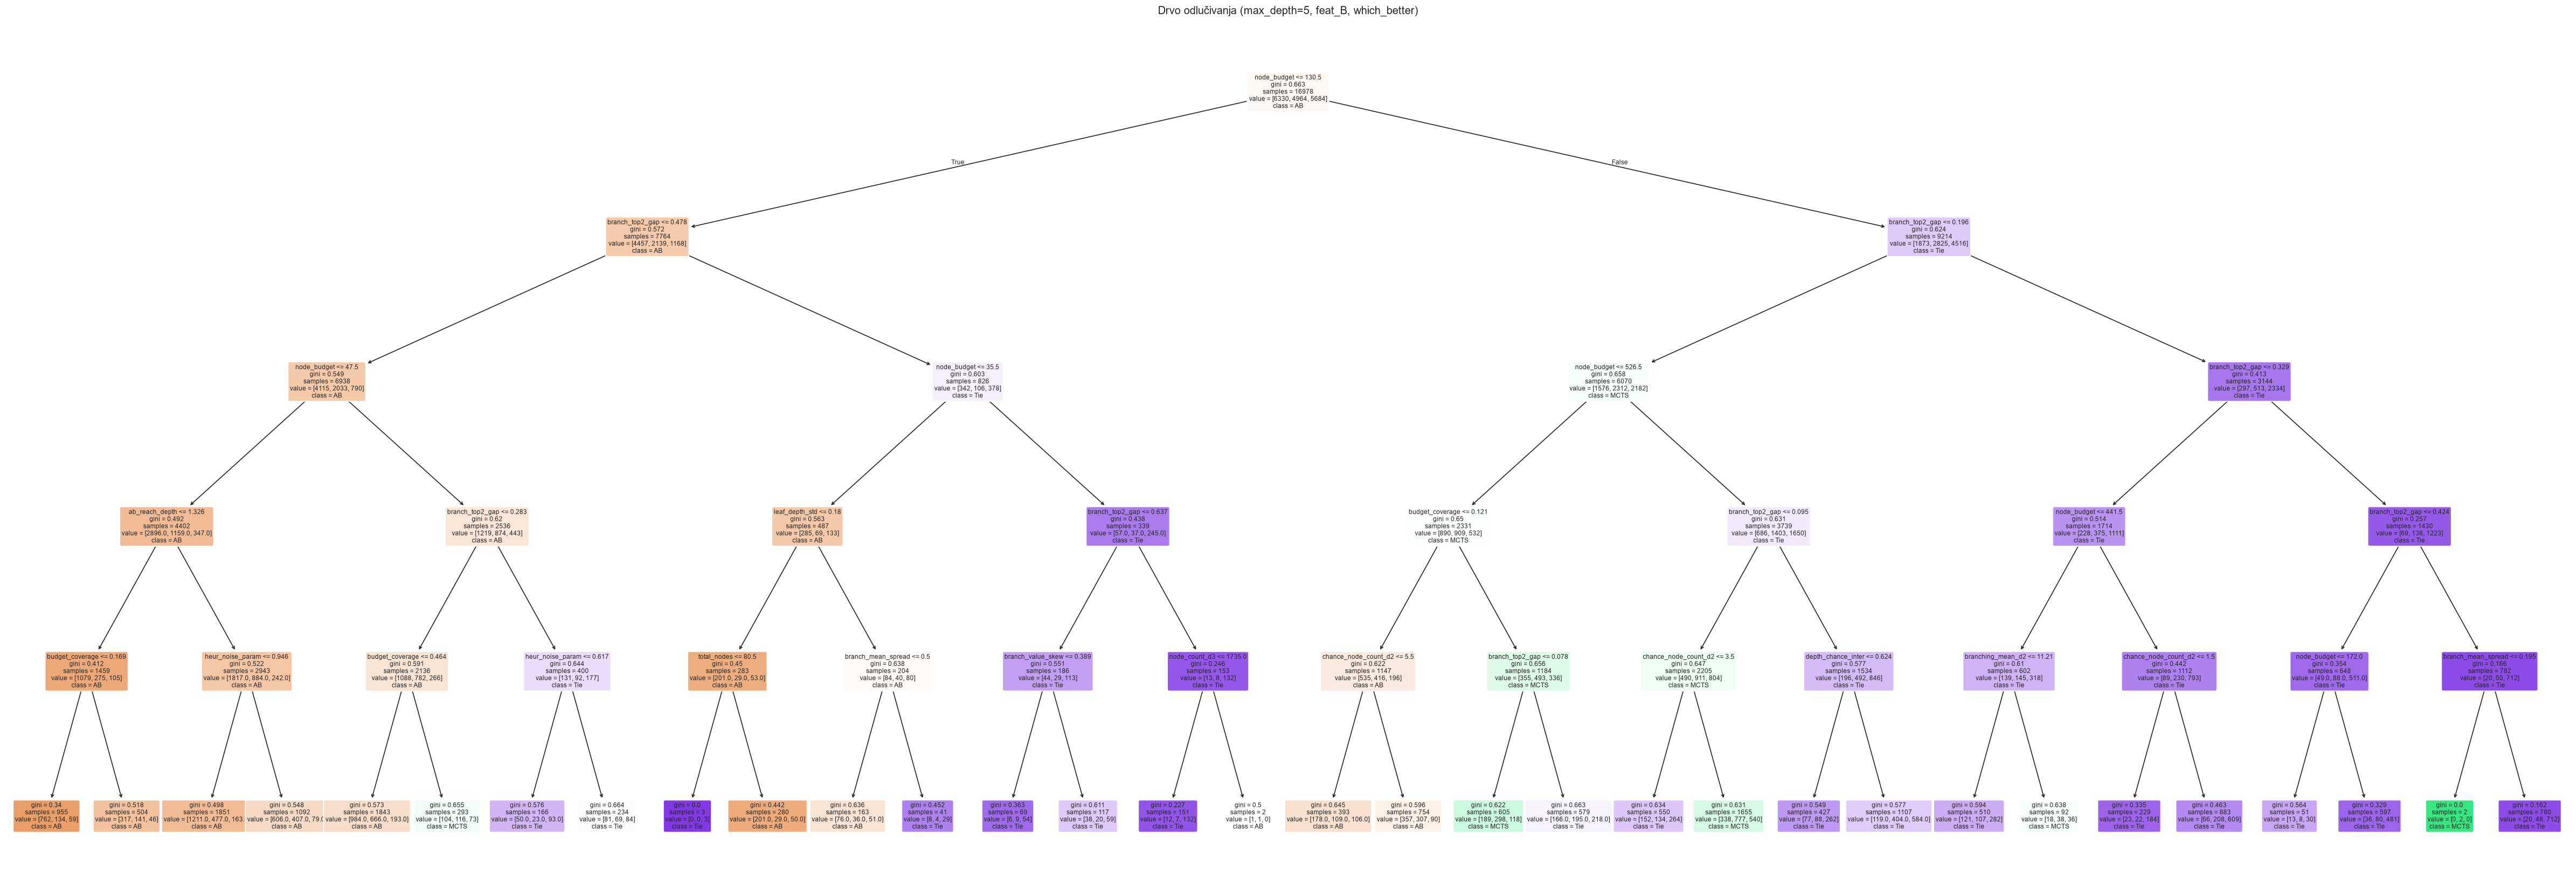

In [10]:
dt_simple = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_simple.fit(X_B, y_better)

print(f"Tačnost na trening skupu (max_depth=5): {dt_simple.score(X_B, y_better):.3f}")
print(f"Koren deli po: {feat_B[dt_simple.tree_.feature[0]]} <= {dt_simple.tree_.threshold[0]:.3f}")

fig, ax = plt.subplots(figsize=(40, 14))
plot_tree(
    dt_simple,
    feature_names=feat_B,
    class_names=label_names,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
plt.title("Drvo odlučivanja (max_depth=5, feat_B, which_better)")
plt.tight_layout()
plt.savefig("../plots/classification/02_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()

 `node_budget` - ima veliki uticaj na učinak i MCTS i AB zato se po njemu i prvo grana
 
`branch_top2_gap` - margina između prva dva poteza, ovo najviše govori o težini stabla, a za laka stabla će verovatno oba naći isti potez

Možemo videti i da je  `chance_density` jedan od atributa od kojih zavisi dal će AB biti bolji 
 
Primećuje se i da AB radi bolje na niskim budžetima i tu se bolje snalaz od MCTS kad je uzak gap, dok kad MCTS ima dovoljno budžeta on bolje ispita stablo i jači je od AB

## 3. Važnost atributa

Važnost atributa u Slučajnim šumama meri se smanjenjem Ginijevog 
indeksa nečistoće pri podeli čvorova

XGBoost mere važnost kao ukupan Gain: prosečno smanjenje greške
pri svakoj podeli po tom atributu


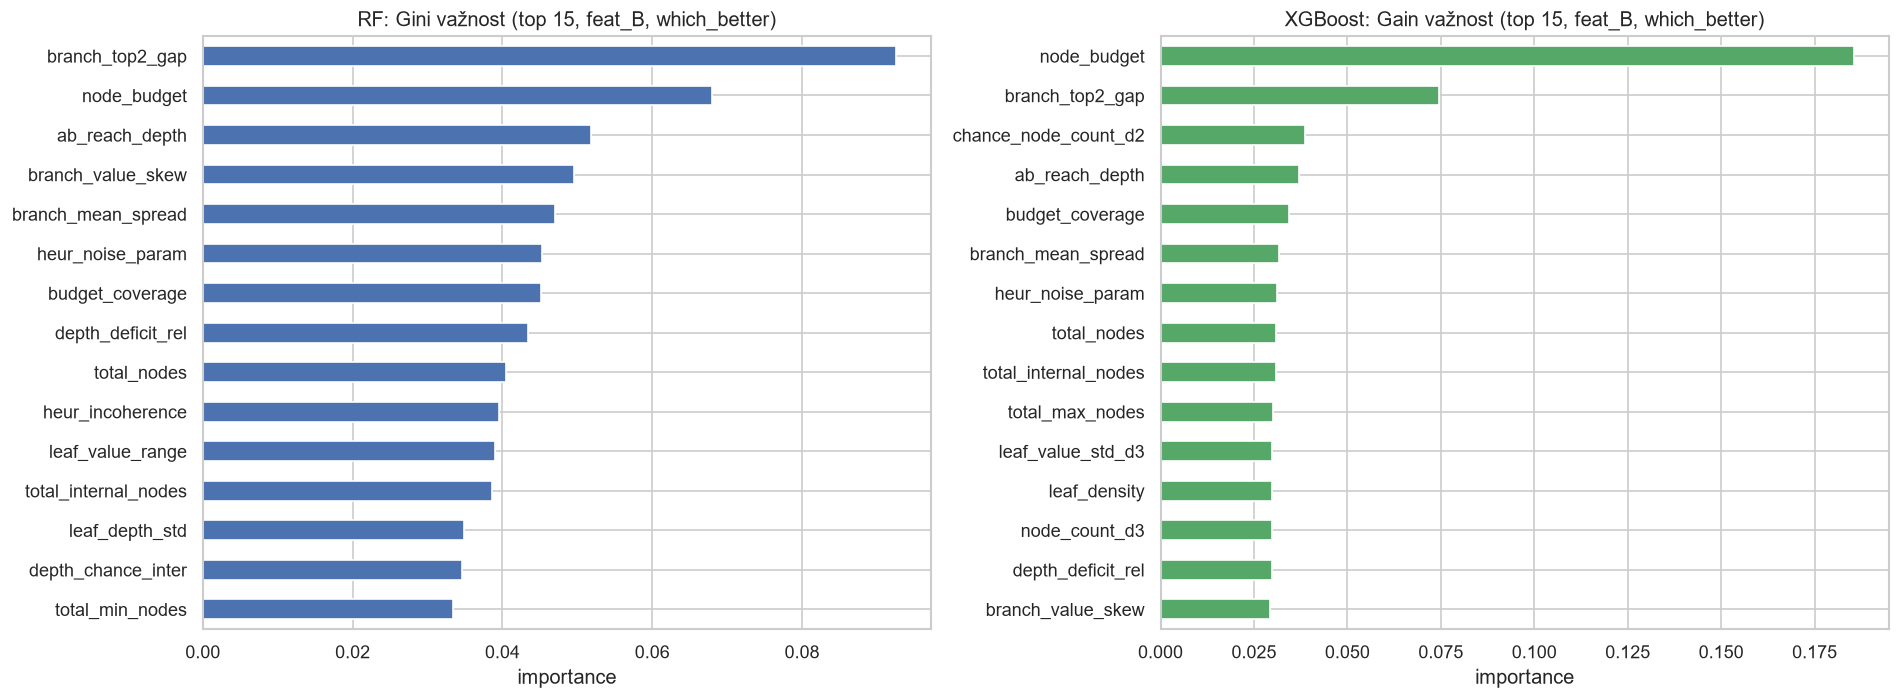

In [12]:
rf_imp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_imp.fit(X_B, y_better)
rf_importance = pd.Series(rf_imp.feature_importances_, index=feat_B).sort_values(ascending=False)

xgb_imp = XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric="mlogloss", n_jobs=-1)
xgb_imp.fit(X_B, y_better)
xgb_importance = pd.Series(xgb_imp.feature_importances_, index=feat_B).sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importance.head(top_n).sort_values().plot.barh(ax=axes[0], color=POS_COLOR)
axes[0].set_title(f"RF: Gini važnost (top {top_n}, feat_B, which_better)")
axes[0].set_xlabel("importance")

xgb_importance.head(top_n).sort_values().plot.barh(ax=axes[1], color=XGB_COLOR)
axes[1].set_title(f"XGBoost: Gain važnost (top {top_n}, feat_B, which_better)")
axes[1].set_xlabel("importance")

plt.tight_layout()
plt.savefig("../plots/classification/04_feature_importance.png", dpi=120)
plt.show()

## 4. ab_correct i mcts_correct binarne ciljne promenljive

Za svaki algoritam posebno: može li se iz atributa stabla predvideti
da li će algoritam pronaći optimalni potez?

**ROC krive** prikazuju kompromis između stope stvarno pozitivnih (TPR, y-osa)
i stope lažno pozitivnih (FPR, x-osa). AUC (površina ispod ROC krive) bliže 1
znači bolji model


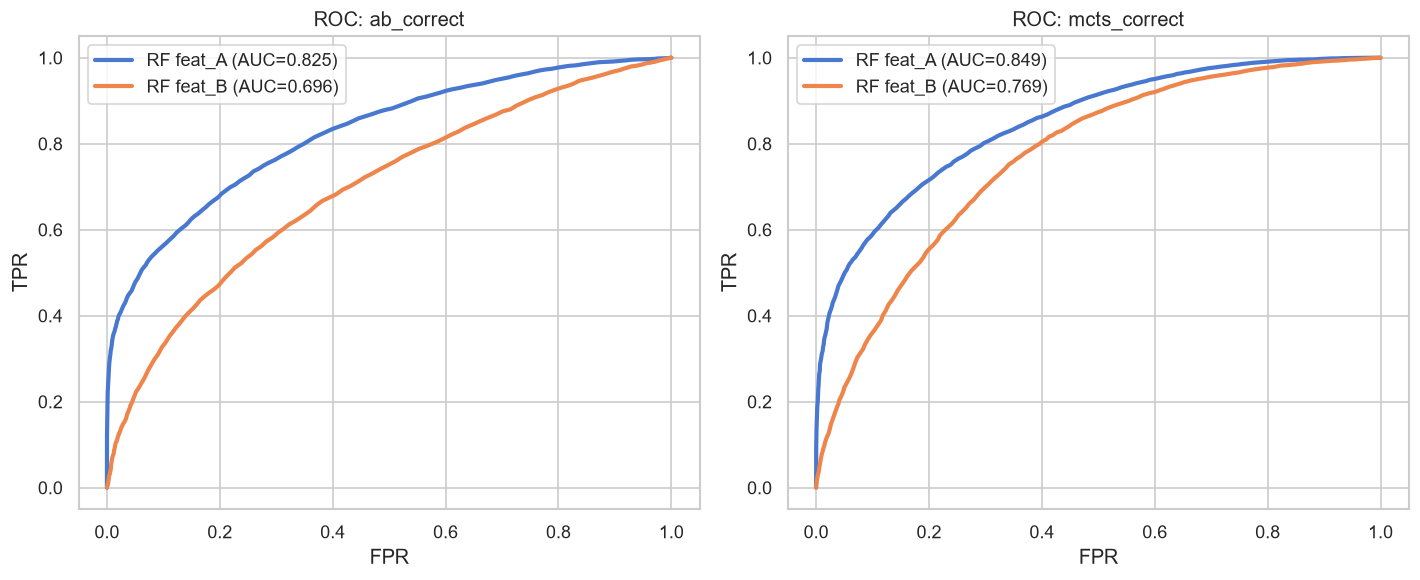

In [13]:
y_ab = df["ab_correct"].values
y_mcts = df["mcts_correct"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for y_bin, ax, title in [
    (y_ab, axes[0], "ab_correct"),
    (y_mcts, axes[1], "mcts_correct"),
]:
    for feat_name, X in [("feat_A", X_A), ("feat_B", X_B)]:
        rf_bin = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        fold_probs = cross_val_predict(rf_bin, X, y_bin, cv=cv5, method="predict_proba")[:, 1]
        fpr, tpr, _ = roc_curve(y_bin, fold_probs)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"RF {feat_name} (AUC={roc_auc:.3f})", linewidth=LINEWIDTH)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"ROC: {title}")
    ax.legend()

plt.tight_layout()
plt.savefig("../plots/classification/05_roc_curves.png", dpi=120)
plt.show()

### 4.1 Uticaj atributa na predikciju (SHAP)

XGBoost za ab_correct na feat_B: koji strukturni atributi stabla
najviše utiču na predikciju greške AB algoritma?

SHAP vrednosti mere doprinos svakog atributa pojedinačnoj predikciji.
Srednja apsolutna SHAP vrednost po atributu daje globalnu meru uticaja.
Vrednosti se dobijaju direktno iz XGBoost-a bez dodatnih biblioteka


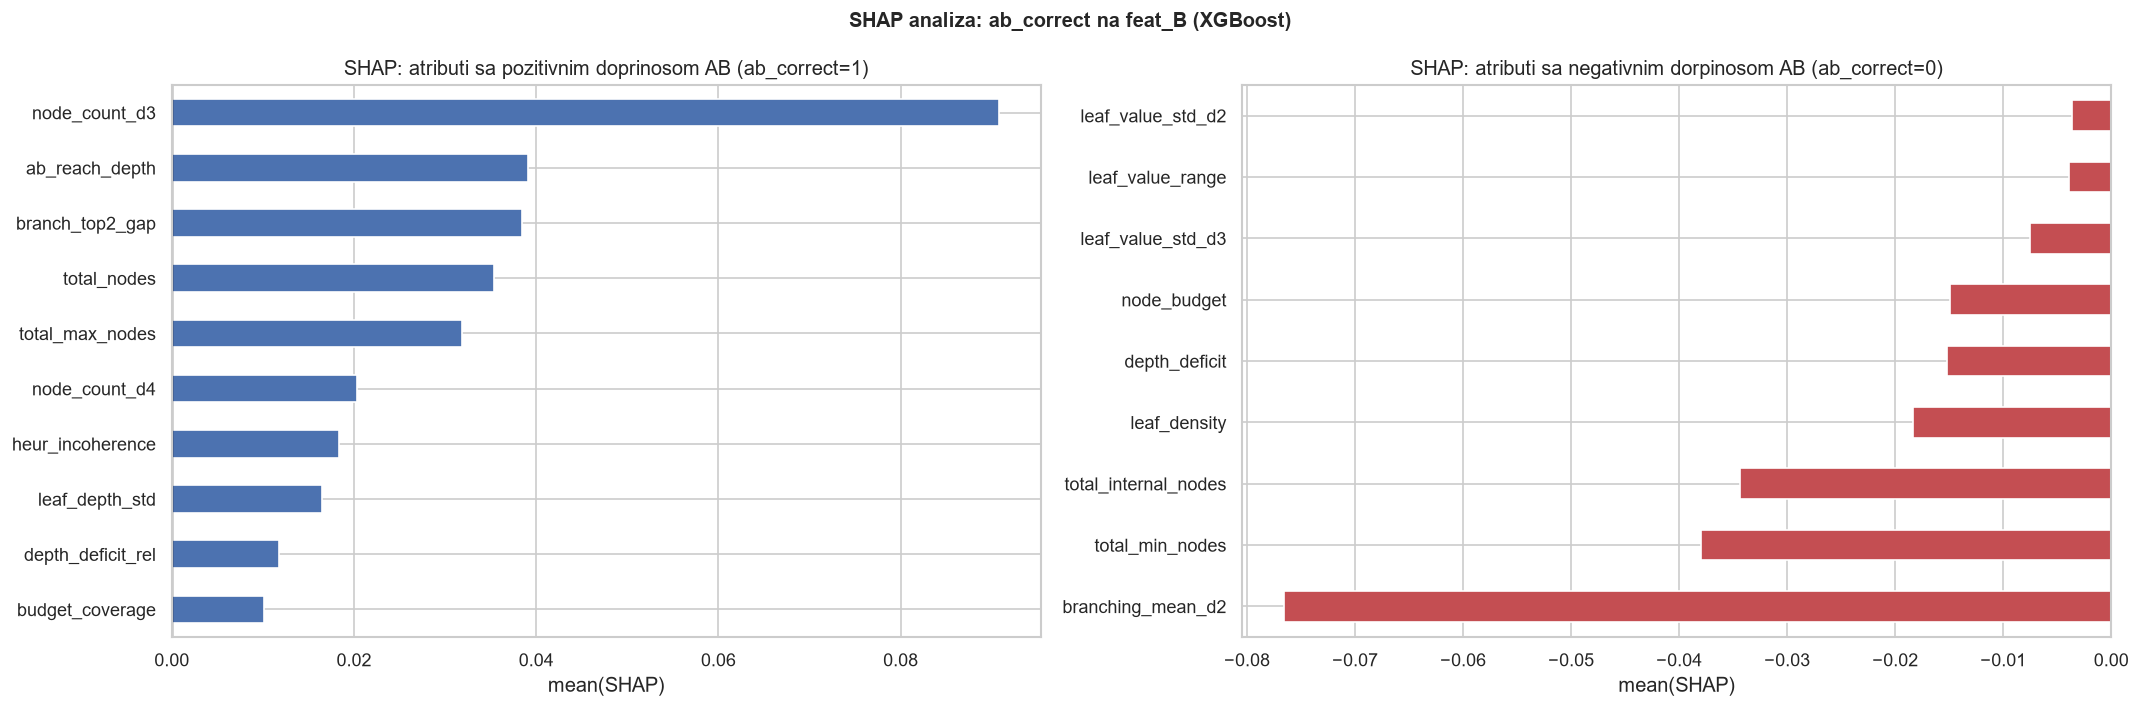

Pozitivan doprinos (10 od 28 atributa):
node_count_d3        0.0908
ab_reach_depth       0.0391
branch_top2_gap      0.0385
total_nodes          0.0354
total_max_nodes      0.0318
node_count_d4        0.0203
heur_incoherence     0.0184
leaf_depth_std       0.0164
depth_deficit_rel    0.0117
budget_coverage      0.0101

Negativan doprinos (9 od 28 atributa):
branching_mean_d2      -0.0766
total_min_nodes        -0.0380
total_internal_nodes   -0.0343
leaf_density           -0.0184
depth_deficit          -0.0152
node_budget            -0.0149
leaf_value_std_d3      -0.0076
leaf_value_range       -0.0039
leaf_value_std_d2      -0.0036


In [14]:
X_B_df = pd.DataFrame(X_B, columns=feat_B)
y_ab = df["ab_correct"].values

xgb_shap = XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric="logloss")
xgb_shap.fit(X_B_df, y_ab)

shap_mat = xgb_shap.get_booster().predict(
    xgb.DMatrix(X_B_df, feature_names=feat_B), pred_contribs=True
)
shap_vals = shap_mat[:, :-1]

shap_signed = pd.Series(shap_vals.mean(axis=0), index=feat_B).sort_values()

top_n = 10
positive_impact = shap_signed[shap_signed > 0].tail(top_n)
negative_impact = shap_signed[shap_signed < 0].head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

positive_impact.sort_values().plot.barh(ax=axes[0], color=POS_COLOR)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("SHAP: atributi sa pozitivnim doprinosom AB (ab_correct=1)")
axes[0].set_xlabel("mean(SHAP)")

negative_impact.sort_values().plot.barh(ax=axes[1], color=NEG_COLOR)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("SHAP: atributi sa negativnim dorpinosom AB (ab_correct=0)")
axes[1].set_xlabel("mean(SHAP)")

plt.suptitle("SHAP analiza: ab_correct na feat_B (XGBoost)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/classification/06_shap_ab_correct.png", dpi=120)
plt.show()

print(f"Pozitivan doprinos ({len(positive_impact)} od {len(feat_B)} atributa):")
print(positive_impact.sort_values(ascending=False).round(4).to_string())
print(f"\nNegativan doprinos ({len(negative_impact)} od {len(feat_B)} atributa):")
print(negative_impact.sort_values().round(4).to_string())

### 4.2 XGBoost: monotona ograničenja

Testiramo dve hipoteze uspostavljene ranije u analizi tako što nateramo XGBoost da ih poštuje kao tvrdo ograničenje, pa poredimo tačnost sa slobodnim modelom:

- **`ab_reach_depth`** što je veći budžet u odnosu na faktor grananja, AB je pouzdaniji (44%->75% tačnosti).
- **`heur_incoherence`** što je heuristika nekoherentnija (više se ne slaže sa vrednošću izvedenom iz dece), AB je manje pouzdan (59.8%->41.6% tačnosti, čisto monotono).

Ako ograničeni model postiže sličan rezultat kao slobodan, podaci potvrđuju obe hipoteze. 

In [15]:
constraints = tuple(
    1 if f == "ab_reach_depth" else (-1 if f == "heur_incoherence" else 0)
    for f in feat_B
)

y_ab = df["ab_correct"].values
X_B_df = pd.DataFrame(X_B, columns=feat_B)

xgb_free = XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric="logloss")
xgb_mono = XGBClassifier(
    n_estimators=200, random_state=42, verbosity=0, eval_metric="logloss",
    monotone_constraints=constraints
)

score_free = cross_val_score(xgb_free, X_B_df, y_ab, cv=cv5, scoring="f1_macro").mean()
score_mono = cross_val_score(xgb_mono, X_B_df, y_ab, cv=cv5, scoring="f1_macro").mean()

print(f"XGB slobodan, macro-F1: {score_free:.3f}")
print(f"XGB monotono, macro-F1: {score_mono:.3f}")
print(f"Razlika: {score_mono - score_free:+.3f}")
print()
if abs(score_mono - score_free) < 0.01:
    print("Ograničenja nisu naškodila: hipoteza se slaže sa podacima")
elif score_mono < score_free:
    print("Ograničenja su malo naškodila: podaci imaju izuzetke koje hipoteza ne predviđa")
else:
    print("Ograničenja su pomogla: slobodan model je naučio relaciju suprotnu od hipoteze")

XGB slobodan, macro-F1: 0.617
XGB monotono, macro-F1: 0.618
Razlika: +0.001

Ograničenja nisu naškodila: hipoteza se slaže sa podacima


## 5. margin_category: koliko je odluka jasna?

Ordinalna promenljiva sa tri kategorije: low (margin < 0.1), medium (0.1-0.4), high (> 0.4).

**Pitanje:** može li se iz samo strukturnih atributa stabla predvideti margina između najboljeg i drugog najboljeg poteza?

Stabla sa visokim marginom su ona na kojima selekcija algoritma
najviše utiče na ishod: pogrešan potez ima veliku cenu

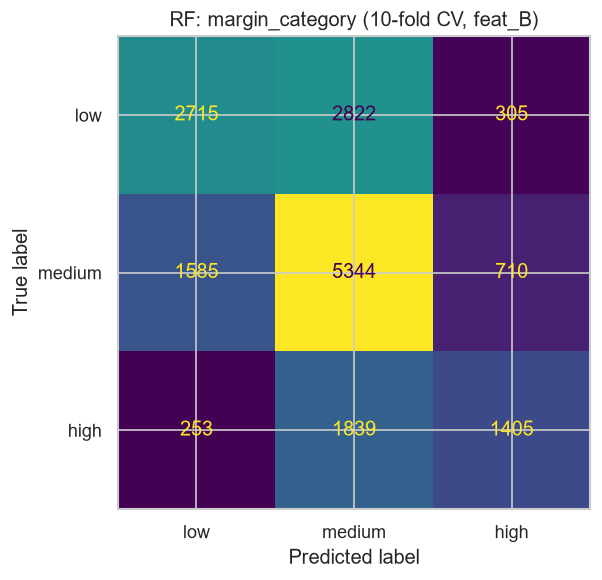

              precision    recall  f1-score   support

         low       0.60      0.46      0.52      5842
      medium       0.53      0.70      0.61      7639
        high       0.58      0.40      0.47      3497

    accuracy                           0.56     16978
   macro avg       0.57      0.52      0.53     16978
weighted avg       0.57      0.56      0.55     16978



In [16]:
y_margin = df["margin_category_enc"].values  # 0=low, 1=medium, 2=high
margin_labels = ["low", "medium", "high"]

rf_margin = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
margin_pred = cross_val_predict(rf_margin, X_B, y_margin, cv=cv10)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_margin, margin_pred,
    display_labels=margin_labels,
    ax=ax, colorbar=False
)
ax.set_title("RF: margin_category (10-fold CV, feat_B)")
plt.tight_layout()
plt.savefig("../plots/classification/07_margin_confusion.png", dpi=120)
plt.show()

print(classification_report(y_margin, margin_pred, target_names=margin_labels))

## 6. tree_difficulty: koliko je stablo teško za predviđanje?

Ordinalna promenljiva sa tri kategorije izvedena iz `which_algo`:
easy (oba algoritma tačna), medium (jedan tačan), hard (nijedan tačan)

Pitanje: može li se iz samo strukturnih atributa stabla predvideti koliko
će lako algorimi pronaći optimalan potez?

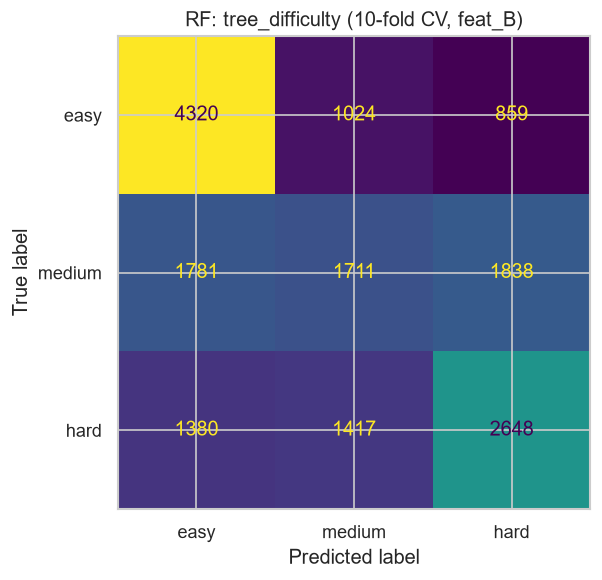

              precision    recall  f1-score   support

        easy       0.58      0.70      0.63      6203
      medium       0.41      0.32      0.36      5330
        hard       0.50      0.49      0.49      5445

    accuracy                           0.51     16978
   macro avg       0.49      0.50      0.49     16978
weighted avg       0.50      0.51      0.50     16978



In [17]:
y_diff = df["tree_difficulty_enc"].values
diff_labels = ["easy", "medium", "hard"]

rf_diff = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
diff_pred = cross_val_predict(rf_diff, X_B, y_diff, cv=cv10)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_diff, diff_pred,
    display_labels=diff_labels,
    ax=ax, colorbar=False
)
ax.set_title("RF: tree_difficulty (10-fold CV, feat_B)")
plt.tight_layout()
plt.savefig("../plots/classification/08_difficulty_confusion.png", dpi=120)
plt.show()

print(classification_report(y_diff, diff_pred, target_names=diff_labels))

Oba targeta predviđaju koliko je pozicija teška i zavise od uglavnom istih atributa `branch_top2_gap`, `branch_mean_spread`, `branch_value_skew`, `heur_incoherence`, `leaf_value_range`. Razlog zašto je prvi uspešniji je zato što uopšte ne zavisi od pokretanja algoritma te izbegava i odatle dobijen šum.

## 7. which_algo: ko je pronašao optimalni potez?

Sporedno pitanje, ovde se pita ko je pogodio globalno optimalan potez.

Klase: `AB` (samo AB), `Both` (oba tačna), `MCTS` (samo MCTS), `Neither` klasa je izbačena jer ova stabla imaju previše šuma i otežavaju predikciju. Prikazuju se macro-F1, matrica konfuzije i izveštaj po klasi na `feat_B` iz same strukture stabla, bez pokretanja algoritama.

Raspodela klasa which_algo (pre odbacivanja Neither):
  AB         2574  (15.2%)
  Both       6203  (36.5%)
  MCTS       2756  (16.2%)
  Neither    5445  (32.1%)

Odbaceno 5445 'Neither' stabala (32.1%) - preostalo 11533 redova



RF: macro-F1 = 0.521 ± 0.018


XGB: macro-F1 = 0.528 ± 0.014


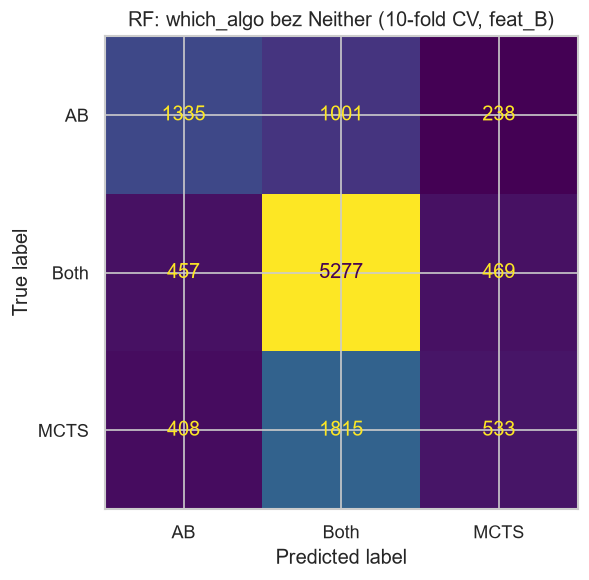

              precision    recall  f1-score   support

          AB       0.61      0.52      0.56      2574
        Both       0.65      0.85      0.74      6203
        MCTS       0.43      0.19      0.27      2756

    accuracy                           0.62     11533
   macro avg       0.56      0.52      0.52     11533
weighted avg       0.59      0.62      0.59     11533

Poredjenje na feat_B (28 atributa): which_better RF=0.554 naspram which_algo (bez Neither) RF=0.521

Odbaceno i Neither i Both - preostalo 5330 redova (samo AB i MCTS)



RF: macro-F1 = 0.712 ± 0.019


XGB: macro-F1 = 0.689 ± 0.015


In [ ]:
y_algo_full = df["which_algo_enc"].values
algo_labels_full = ["AB", "Both", "MCTS", "Neither"]  # abecedni redosled (LabelEncoder iz 02)

print("Raspodela klasa which_algo (pre odbacivanja Neither):")
for i, nm in enumerate(algo_labels_full):
    print(f"  {nm:<8} {(y_algo_full == i).sum():>6}  ({(y_algo_full == i).mean():.1%})")
print()

# Neither odbacen, ta stabla nemaju
# zajednicki strukturni potpis 
# i samo dodaju sum bez korisnog signala za preostale tri klase
neither_code = algo_labels_full.index("Neither")
mask = y_algo_full != neither_code
X_B_algo = X_B[mask]
y_algo = y_algo_full[mask]
algo_labels = [l for l in algo_labels_full if l != "Neither"]

print(f"Odbaceno {(~mask).sum()} 'Neither' stabala ({(~mask).mean():.1%}) - preostalo {len(y_algo)} redova\n")

rf_algo = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb_algo = XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric="mlogloss", n_jobs=-1)

algo_scores = {}
for name, model in [("RF", rf_algo), ("XGB", xgb_algo)]:
    scores = cross_val_score(model, X_B_algo, y_algo, cv=cv10, scoring="f1_macro")
    algo_scores[name] = scores.mean()
    print(f"{name}: macro-F1 = {scores.mean():.3f} ± {scores.std():.3f}")

algo_pred = cross_val_predict(rf_algo, X_B_algo, y_algo, cv=cv10)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_algo, algo_pred, display_labels=algo_labels, ax=ax, colorbar=False)
ax.set_title("RF: which_algo bez Neither (10-fold CV, feat_B)")
plt.tight_layout()
plt.savefig("../plots/classification/09_which_algo_confusion.png", dpi=120)
plt.show()

print(classification_report(y_algo, algo_pred, target_names=algo_labels))

better_b_f1 = results["B"]["RF"]
print(f"Poredjenje na feat_B ({len(feat_B)} atributa): "
      f"which_better RF={better_b_f1:.3f} naspram which_algo (bez Neither) RF={algo_scores['RF']:.3f}")

# sad odbacujemo i Both - cist AB naspram MCTS
mask_ab_mcts = (y_algo_full == algo_labels_full.index("AB")) | (y_algo_full == algo_labels_full.index("MCTS"))
X_B_ab_mcts = X_B[mask_ab_mcts]
# remapirano na uzastopne labele {0,1}
y_ab_mcts = (y_algo_full[mask_ab_mcts] == algo_labels_full.index("MCTS")).astype(int)  # 0=AB, 1=MCTS
am_label_codes = [0, 1]

print(f"\nOdbaceno i Neither i Both - preostalo {mask_ab_mcts.sum()} redova (samo AB i MCTS)\n")

rf_am = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb_am = XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric="mlogloss", n_jobs=-1)

am_scores = {}
for name, model in [("RF", rf_am), ("XGB", xgb_am)]:
    scores = cross_val_score(model, X_B_ab_mcts, y_ab_mcts, cv=cv10, scoring="f1_macro")
    am_scores[name] = scores.mean()
    print(f"{name}: macro-F1 = {scores.mean():.3f} ± {scores.std():.3f}")

am_pred = cross_val_predict(rf_am, X_B_ab_mcts, y_ab_mcts, cv=cv10)

`which_algo` je dosta teži cilj, teže je predvideti kada će algoritmi pronaći baš tačan potez, pogotovo zato što kad su stabla laka oba ga pronalaze trivijalno, a na težim stablima se obično ni jedan ni drugi ne nađu baš optimalni potez. Jako je teško pronaći stabla u kojima samo AB pronalazi optimum i gde samo MCTS.

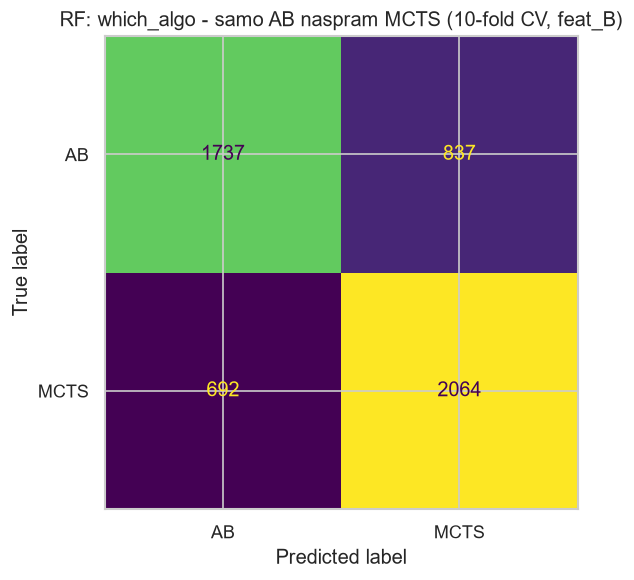

              precision    recall  f1-score   support

          AB       0.72      0.67      0.69      2574
        MCTS       0.71      0.75      0.73      2756

    accuracy                           0.71      5330
   macro avg       0.71      0.71      0.71      5330
weighted avg       0.71      0.71      0.71      5330



In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_ab_mcts, am_pred,
    labels=am_label_codes,
    display_labels=["AB", "MCTS"],
    ax=ax, colorbar=False
)
ax.set_title("RF: which_algo - samo AB naspram MCTS (10-fold CV, feat_B)")
plt.tight_layout()
plt.savefig("../plots/classification/13_which_algo_ab_vs_mcts.png", dpi=120)
plt.show()

print(classification_report(y_ab_mcts, am_pred, labels=am_label_codes, target_names=["AB", "MCTS"]))

Kad se izbaci klasa Both dobijamo balansiranije skupove na kojima je dosta lakše uvideti rezliku pa se dobijaju i dosta bolji rezultati. Klasa MCTS je dosta bliska Both koji je brojniji pa je obično proguta, zato ovde vidimo znatno poboljšanje recall-a i f1 skora za MCTS.